**EXPERIMENT ONE**

Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 1: 0.8584 MB
Global model accuracy after round 1: 0.9757
Convergence achieved at round 1 with accuracy 0.9757
Convergence time: 35.46 seconds
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Communication overhead for round 2: 0.8584 MB
Global model accuracy after round 2: 0.9846
Round 3/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on 

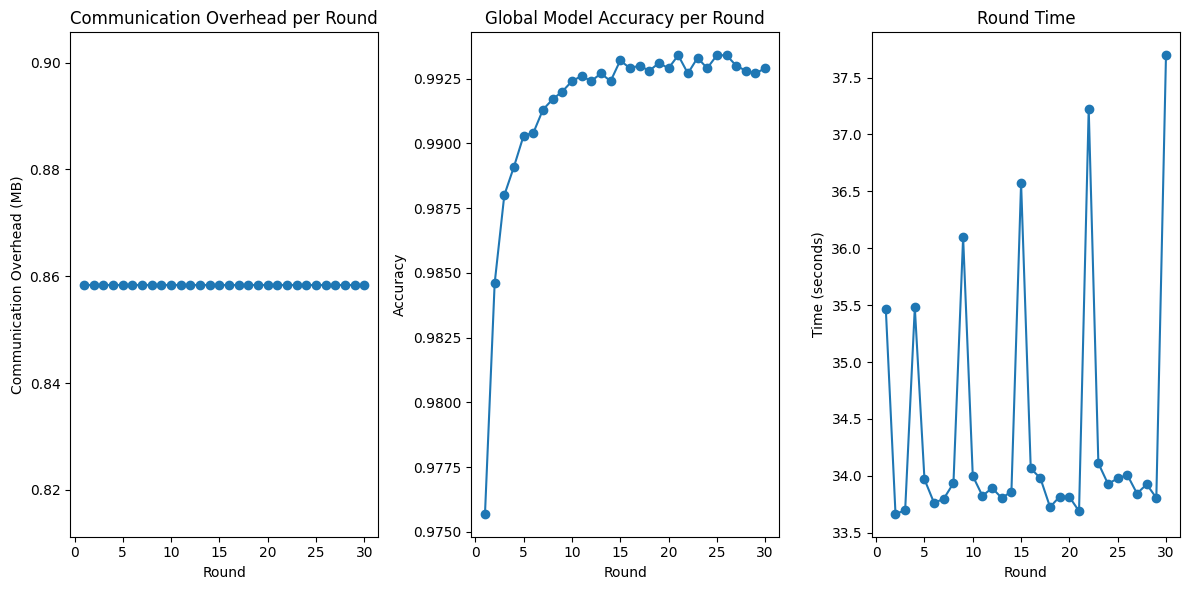

In [ ]:
#pre processing libraries
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Loading and preprocessing the MNIST dataset
def load_and_preprocess_data()
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalizing the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshaping the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Converting to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Printing shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Defining the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Creating federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=10):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measuring communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 10
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Loading and preprocessing data
train_ds, test_ds = load_and_preprocess_data()

# Creating federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Creating global model
input_shape = (28, 28, 1)  # Inputing shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initializing variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Training on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Creating local model and setting global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Getting client data
        client_ds = federated_train_data[client_id]

        # Training local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collecting local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measuring communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Updating global model weights
    global_model.set_weights(averaged_weights)

    # Evaluating the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Checking for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Recording round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluating the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Printing the  total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Printing convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plotting communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plotting accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plotting round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT TWO**

Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Communication overhead for round 1: 0.8584 MB
Global model accuracy after round 1: 0.9628
Convergence achieved at round 1 with accuracy 0.9628
Convergence time: 57.32 seconds
Round 2/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 

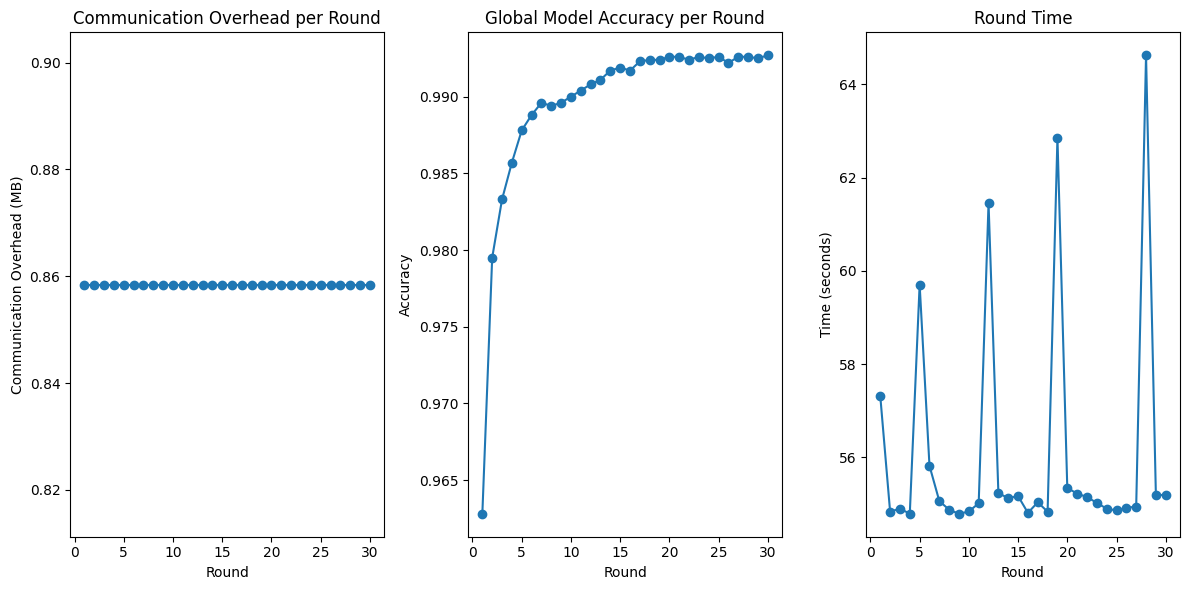

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Loading and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalizing the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=20):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 20
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT THREE**

Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Communication overhead for round 1: 0.8584 MB
Global model accuracy after round 1: 0.9529
Convergence achieved at round 1 with accuracy 0.9529
Convergence time: 79.25 seconds
Round 2/30
Training o

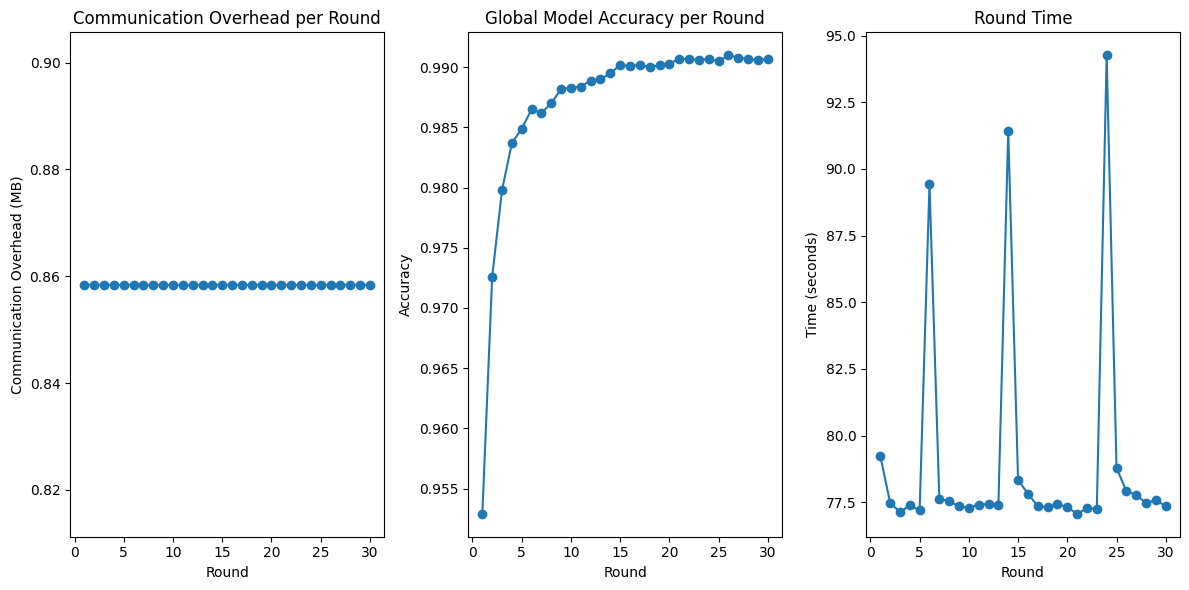

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=30):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 30
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FOUR**

Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 3

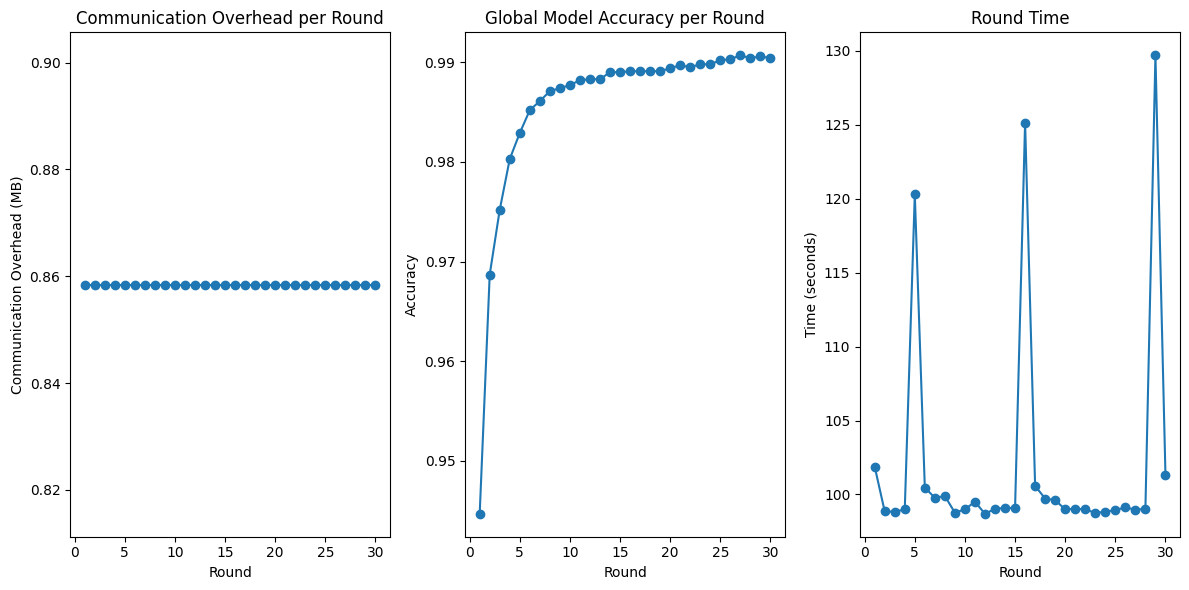

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=40):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 40
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT FIVE**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on c

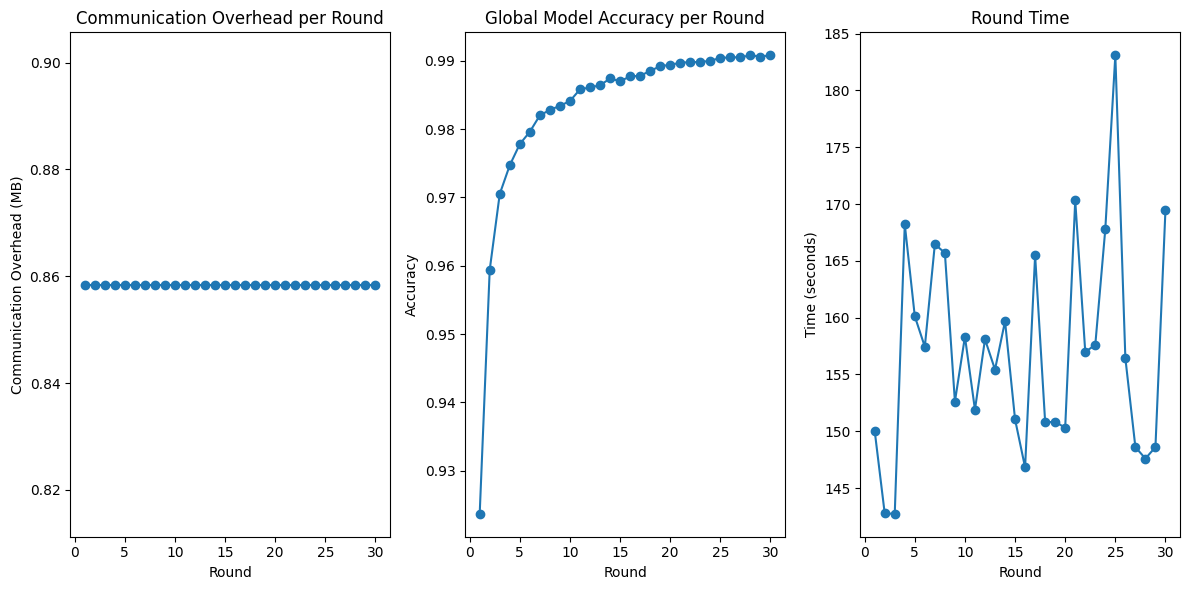

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=50):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 50
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**EXPERIMENT SIX**

Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on client 37
Training on client 38
Training on client 3

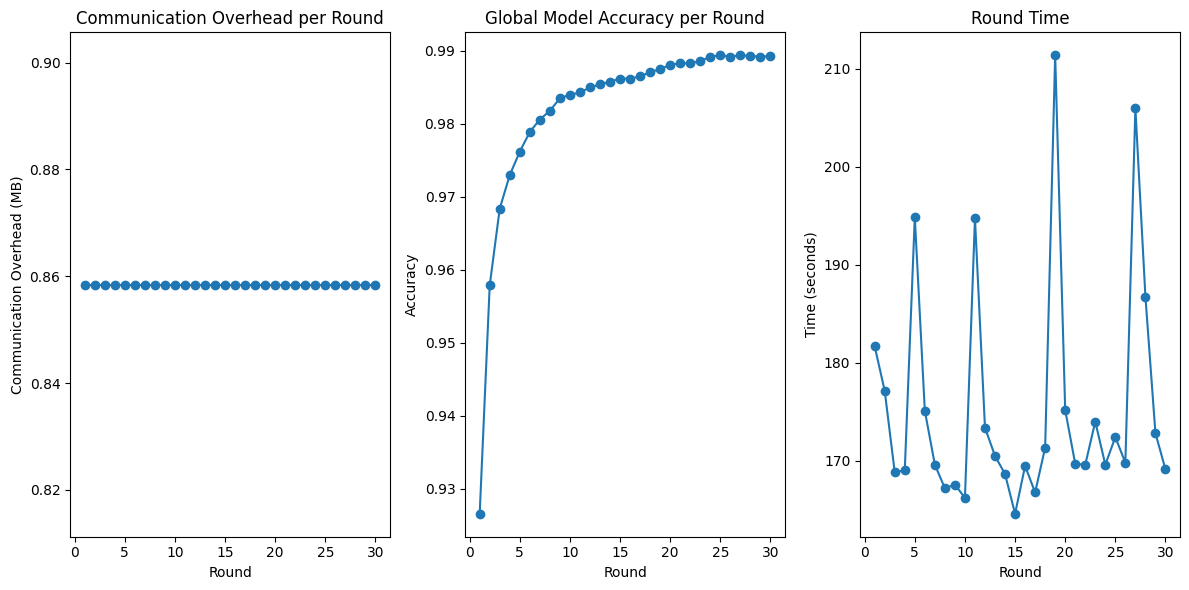

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=60):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 60
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**Experiment Seven**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on c

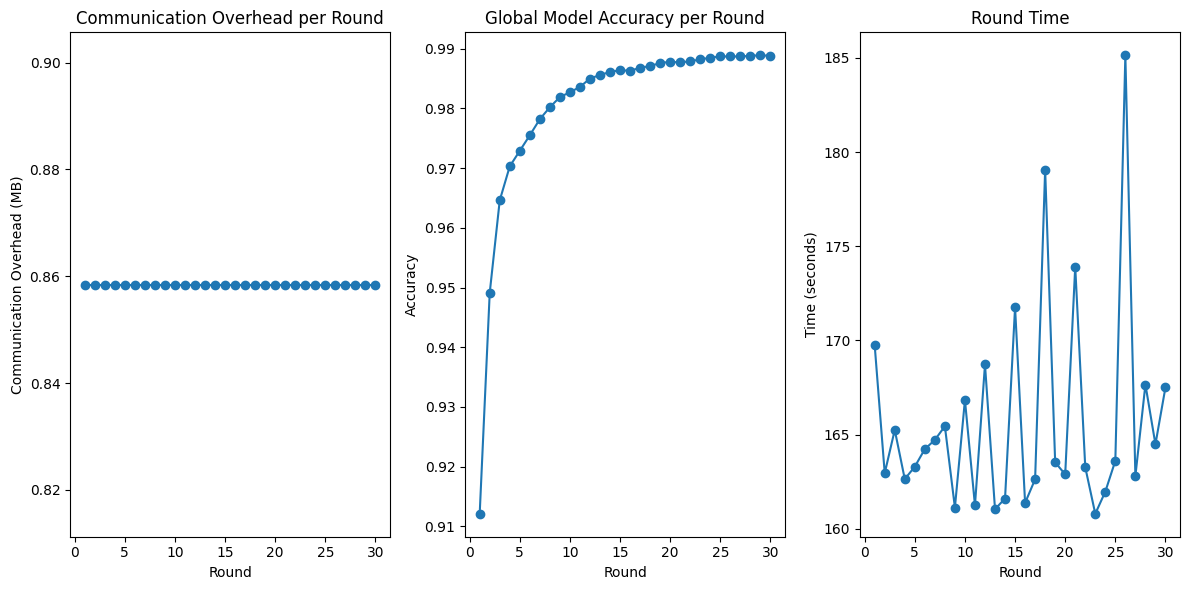

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=70):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 70
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**Experiment Eight**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on c

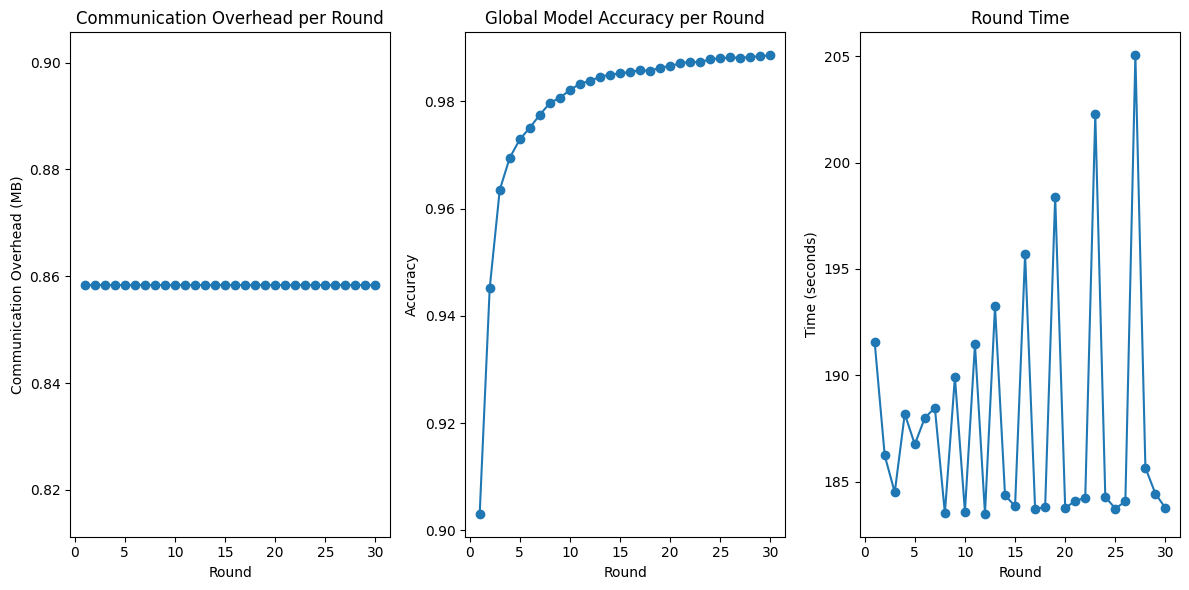

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=80):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 80
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.5 MB/s eta 0:00:00


**Experiment nine**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on c

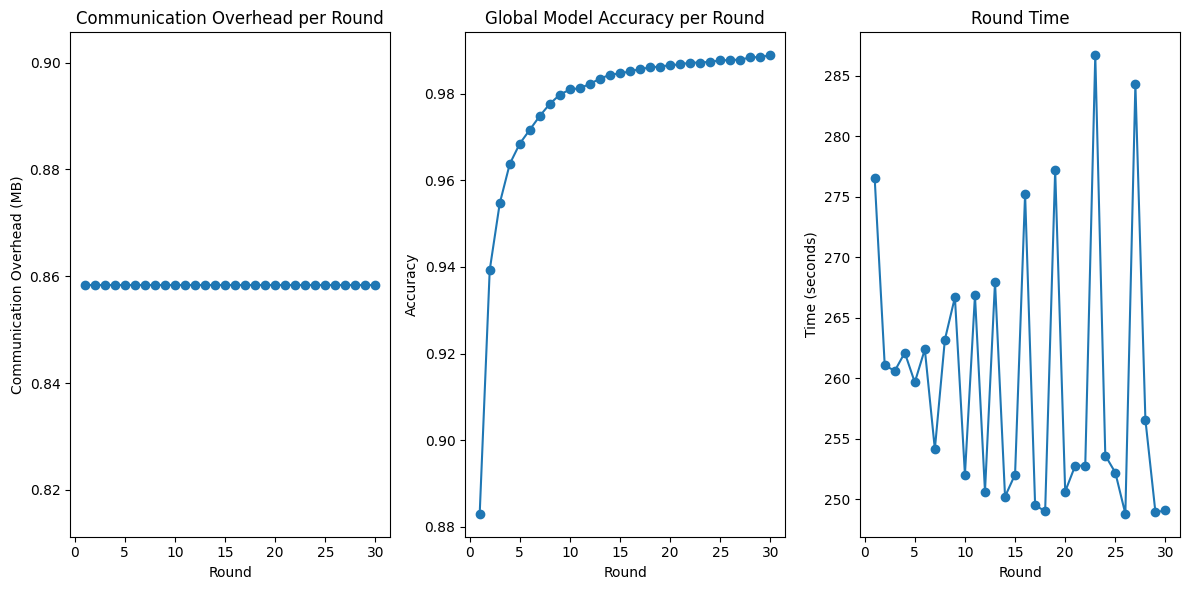

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=90):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 90
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  # Define an accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**Experiment Ten**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Round 1/30
Training on client 1
Training on client 2
Training on client 3
Training on client 4
Training on client 5
Training on client 6
Training on client 7
Training on client 8
Training on client 9
Training on client 10
Training on client 11
Training on client 12
Training on client 13
Training on client 14
Training on client 15
Training on client 16
Training on client 17
Training on client 18
Training on client 19
Training on client 20
Training on client 21
Training on client 22
Training on client 23
Training on client 24
Training on client 25
Training on client 26
Training on client 27
Training on client 28
Training on client 29
Training on client 30
Training on client 31
Training on client 32
Training on client 33
Training on client 34
Training on client 35
Training on client 36
Training on c

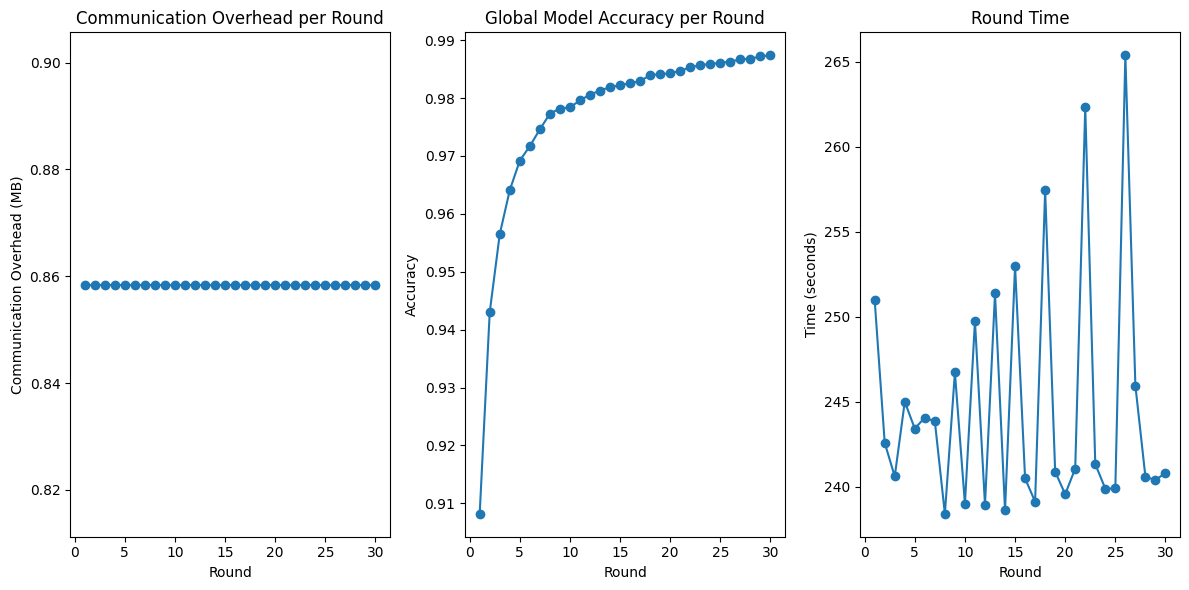

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Load and preprocess the MNIST dataset
def load_and_preprocess_data():
    # Load the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Define the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')  # 10 classes for MNIST
    ])
    return model

# Create federated data by splitting the dataset among clients
def create_federated_data(dataset, num_clients=100):
    client_data = []
    data_per_client = len(dataset) // num_clients
    for i in range(num_clients):
        client_ds = dataset.skip(i * data_per_client).take(data_per_client)
        client_data.append(client_ds)
    return client_data

# Measure communication overhead
def measure_communication_overhead(weights):
    return sum([np.prod(w.shape) for w in weights]) * 4 / (1024 * 1024)  # in MB

# Federated learning parameters
num_clients = 100
num_rounds = 30
local_epochs = 3
accuracy_threshold = 0.70  #  accuracy threshold for convergence speed

# Load and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Create federated data for each client
federated_train_data = create_federated_data(train_ds, num_clients)

# Create global model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
global_model = create_cnn_model(input_shape)
global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Initialize variables to measure communication overhead and convergence speed
total_communication_overhead = 0
convergence_round = None
start_time = time.time()

# Lists to store metrics for visualization
communication_overheads = []
accuracies = []
round_times = []

# Federated learning loop
for round_num in range(num_rounds):
    print(f"Round {round_num + 1}/{num_rounds}")

    local_weights = []
    round_start_time = time.time()

    # Train on each client
    for client_id in range(num_clients):
        print(f"Training on client {client_id + 1}")

        # Create local model and set global weights
        local_model = create_cnn_model(input_shape)
        local_model.set_weights(global_model.get_weights())
        local_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        # Get client data
        client_ds = federated_train_data[client_id]

        # Train local model
        local_model.fit(client_ds, epochs=local_epochs, batch_size=32, verbose=0)

        # Collect local model weights
        local_weights.append(local_model.get_weights())

    # Federated averaging: Aggregate local weights
    averaged_weights = [np.mean([local_weights[j][i] for j in range(num_clients)], axis=0)
                        for i in range(len(local_weights[0]))]

    # Measure communication overhead
    round_communication_overhead = measure_communication_overhead(averaged_weights)
    total_communication_overhead += round_communication_overhead
    communication_overheads.append(round_communication_overhead)
    print(f"Communication overhead for round {round_num + 1}: {round_communication_overhead:.4f} MB")

    # Update global model weights
    global_model.set_weights(averaged_weights)

    # Evaluate the global model
    loss, accuracy = global_model.evaluate(test_ds, verbose=0)
    accuracies.append(accuracy)
    print(f"Global model accuracy after round {round_num + 1}: {accuracy:.4f}")

    # Check for convergence
    if convergence_round is None and accuracy >= accuracy_threshold:
        convergence_round = round_num + 1
        convergence_time = time.time() - start_time
        print(f"Convergence achieved at round {convergence_round} with accuracy {accuracy:.4f}")
        print(f"Convergence time: {convergence_time:.2f} seconds")

    # Record round time
    round_time = time.time() - round_start_time
    round_times.append(round_time)

# Evaluate the final global model
final_loss, final_accuracy = global_model.evaluate(test_ds, verbose=0)
print(f"Final global model accuracy: {final_accuracy:.4f}")

# Print total communication overhead
print(f"Total communication overhead: {total_communication_overhead:.4f} MB")

# Print convergence information if not already printed
if convergence_round is None:
    convergence_time = time.time() - start_time
    print(f"Convergence not achieved within {num_rounds} rounds.")
else:
    print(f"Convergence achieved at round {convergence_round} with accuracy {final_accuracy:.4f}")
    print(f"Convergence time: {convergence_time:.2f} seconds")

# Visualization
rounds = list(range(1, num_rounds + 1))

plt.figure(figsize=(12, 6))

# Plot communication overhead
plt.subplot(1, 3, 1)
plt.plot(rounds, communication_overheads, marker='o')
plt.title('Communication Overhead per Round')
plt.xlabel('Round')
plt.ylabel('Communication Overhead (MB)')

# Plot accuracy
plt.subplot(1, 3, 2)
plt.plot(rounds, accuracies, marker='o')
plt.title('Global Model Accuracy per Round')
plt.xlabel('Round')
plt.ylabel('Accuracy')

# Plot round times
plt.subplot(1, 3, 3)
plt.plot(rounds, round_times, marker='o')
plt.title('Round Time')
plt.xlabel('Round')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

**Centralized** **Experiment**

Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28, 1)
Testing labels shape: (10000,)
Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9185 - loss: 0.2831 - val_accuracy: 0.9716 - val_loss: 0.0813
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9840 - loss: 0.0496 - val_accuracy: 0.9852 - val_loss: 0.0430
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9899 - loss: 0.0313 - val_accuracy: 0.9876 - val_loss: 0.0354
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9938 - loss: 0.0199 - val_accuracy: 0.9888 - val_loss: 0.0357
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9951 - loss: 0.0150 - val_accuracy: 0.9905 - val_loss: 0.0313
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9972 - loss: 0.0097 - val_accuracy: 0.9875 - val_loss: 0.0422
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9965 - los

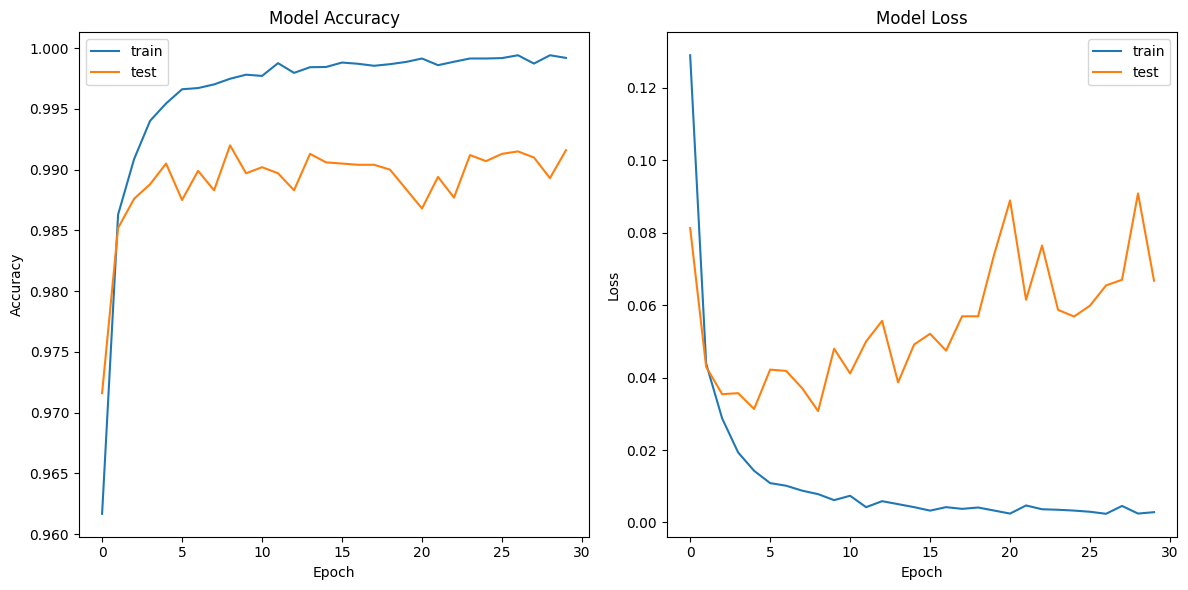

In [ ]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt

# Loading and preprocessing the MNIST dataset
def load_and_preprocess_data():
    # Loading the dataset
    (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize the images to the range [0, 1]
    X_train = X_train.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0

    # Reshape the data to fit the CNN input shape (28x28 images with 1 channel)
    X_train = X_train.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)

    # Convert to TensorFlow datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(32).prefetch(tf.data.experimental.AUTOTUNE)

    # Print shapes of the datasets
    print(f"Training data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Testing data shape: {X_test.shape}")
    print(f"Testing labels shape: {y_test.shape}")

    return train_ds, test_ds

# Defining the global CNN model
def create_cnn_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Loading and preprocess data
train_ds, test_ds = load_and_preprocess_data()

# Creating and compile the model
input_shape = (28, 28, 1)  # Input shape for the MNIST dataset
model = create_cnn_model(input_shape)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training the model
start_time = time.time()
history = model.fit(train_ds, epochs=30, batch_size=32, validation_data=test_ds, verbose=1)
training_time = time.time() - start_time

# Evaluating the model
final_loss, final_accuracy = model.evaluate(test_ds, verbose=0)
print(f"Final model accuracy: {final_accuracy:.4f}")
print(f"Training time: {training_time:.2f} seconds")

# Visualization
plt.figure(figsize=(12, 6))

# Plotting accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()